## 12. Stacking filament images

The following notebook works on developing the code for stacking of filament images with the eRASS:4 survey! :D The aim of the class must be as follows:
1. Squeeze the filaments based on their endpoints


**Author**: Soumya Shreeram <br/>
**Contact email**: shreeram@mpe.mpg.de <br/>
**Date created**: 29th November 2022 <br/>
**Date last editted**: tbd

In [1]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits
from astropy.table import Table, Column, QTable
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18, z_at_value
from astropy import wcs

import numpy as np
import pandas as pd

# system imports
import os
import sys
import importlib as ib
import glob
import copy

from scipy import interpolate
# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Arc
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.colors import LogNorm, Normalize
import seaborn as sns

from reproject import reproject_interp
from reproject.mosaicking import reproject_and_coadd, find_optimal_celestial_wcs

In [2]:
import filaments as fo

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 18}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

In [9]:
this_file = fo.DisPerSEcatalog2eRass(data_set='lc_north_dis',
                                           smoothing_density_f='SD2',
                                           persistence=5,
                                           smoothing_skeleton='S001'
                                           )
# selects the filaments to straighten
selected_entires = this_file.get_selected_filament_ids()

INFO:DisPerSEcatalog2eRass:<DisPerSEcatalog2eRass(data_set=lc_north_dis, smoothing_density_f=SD2, persistence=5, smoothing_skeleton=S001, section=fil)>
INFO:DisPerSEcatalog2eRass:total filaments available 351
INFO:DisPerSEcatalog2eRass:===========

INFO:DisPerSEcatalog2eRass:German half of the sky has:
INFO:DisPerSEcatalog2eRass:Total 220
INFO:DisPerSEcatalog2eRass:Length and orientation cut 11
INFO:DisPerSEcatalog2eRass:Only length cut 18
INFO:DisPerSEcatalog2eRass:Only orientation cut 134
INFO:DisPerSEcatalog2eRass:===========

INFO:DisPerSEcatalog2eRass:Russian half of the sky has:
INFO:DisPerSEcatalog2eRass:Total 131
INFO:DisPerSEcatalog2eRass:Length and orientation cut 21
INFO:DisPerSEcatalog2eRass:Only length cut 28
INFO:DisPerSEcatalog2eRass:Only orientation cut 101
INFO:DisPerSEcatalog2eRass:===========

INFO:DisPerSEcatalog2eRass:masked entries=80


In [62]:
print(len(selected_entires))
np.arange(0, len(selected_entires), 3)

22


array([ 0,  3,  6,  9, 12, 15, 18, 21])

### Putting together the filament sub-images into a single filament image

In [7]:
from astropy.nddata import Cutout2D

In [7]:
print(f"{straighten_filament.directory_name}")
print(f"{straighten_filament.filament_name}")
print(f"{straighten_filament.data_location}")
print(f"crop_size = {straighten_filament.crop_size_Mpc} Mpc")
print(f"crop_size = {straighten_filament.rcrop:.2f} deg")

lc_north_dis_SD2_s5.0_S001
filid94_len_87.69Mpc_7seg_3.19deg_z0.504
/he13srv_local/shreeram/eRass_products
crop_size = 40 Mpc
crop_size = 1.76 deg


### Putting together the straightened image

In [ ]:
straighten_filament = fo.StraightenFilaments(data_set='lc_north_dis',
                                           smoothing_density_f='SD2',
                                           persistence=5,
                                           smoothing_skeleton='S001',
                                           fil_id=94)
straighted_fil, new_x_ends, new_y_ends = straighten_filament.append_straightened_cutouts()

In [74]:
fil_id_arr = straighten_filament.get_selected_filament_ids()
len(fil_id_arr)

INFO:StraightenFilaments:masked entries=80


22

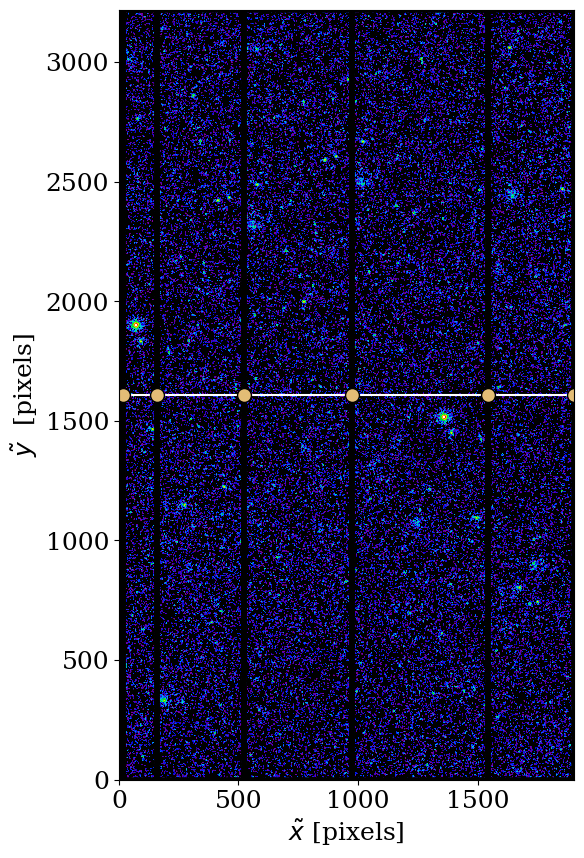

In [72]:
from astropy.visualization import simple_norm

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
#fig.set_facecolor('black')
norm1 = simple_norm(straighted_fil.T, 'log', min_cut=1e-2, max_cut=10) 
ax.plot(new_x_ends, new_y_ends, 'w-o', mfc='#e3bd76', ms=10, mec='k')
for i in range(len(new_x_ends)-1):
    x = new_x_ends[i]
    width = new_x_ends[i+1]-new_x_ends[i]
    height = straighted_fil.T.shape[0]
    rect = patches.Rectangle((x, 0), width, height, ls='-', ec='k', fc='None', lw=4)
    ax.add_patch(rect)
ax.imshow(straighted_fil.T, origin='lower', cmap=fo.custom_colormap(), norm=norm1)
fo.set_labels(ax, r"$\tilde{x}$ [pixels]", r"$\tilde{y}$  [pixels]")
#fo.set_as_white(ax)

In [10]:
straightened_img_shapes = []
for fil_id in selected_entires:
    straighten_filament = fo.StraightenFilaments(data_set='lc_north_dis',
                                           smoothing_density_f='SD2',
                                           persistence=5,
                                           smoothing_skeleton='S001',
                                           fil_id=fil_id)
    straighten_filament.append_straightened_cutouts()
    
    straightened_img_shapes.append(fits.open(straighten_filament.straightened_fil_name)[0].data.shape)

INFO:StraightenFilaments:<DisPerSEcatalog2eRass(data_set=lc_north_dis, smoothing_density_f=SD2, persistence=5, smoothing_skeleton=S001, section=fil)>
INFO:StraightenFilaments:total filaments available 351
INFO:StraightenFilaments:===========

INFO:StraightenFilaments:German half of the sky has:
INFO:StraightenFilaments:Total 220
INFO:StraightenFilaments:Length and orientation cut 11
INFO:StraightenFilaments:Only length cut 18
INFO:StraightenFilaments:Only orientation cut 134
INFO:StraightenFilaments:===========

INFO:StraightenFilaments:Russian half of the sky has:
INFO:StraightenFilaments:Total 131
INFO:StraightenFilaments:Length and orientation cut 21
INFO:StraightenFilaments:Only length cut 28
INFO:StraightenFilaments:Only orientation cut 101
INFO:StraightenFilaments:===========

INFO:StraightenFilaments:fil_id=94
INFO:StraightenFilaments:'proc_v_folder' default set to c020
INFO:StraightenFilaments:'pattern' not set; setting it to the default value of '15'
INFO:StraightenFilaments:'

In [47]:
select = np.where(np.array(straightened_img_shapes)[:, 1]>500)[0]
size_x = np.min(np.array(straightened_img_shapes)[:, 1][select])
size_x

649

In [54]:
#size_x = np.min(np.array(straightened_img_shapes)[:, 1])
size_y = 620
filenames = glob.glob("/he13srv_local/shreeram/eRass_products/lc_north_dis_SD2_s5.0_S001/filid*/rescaled_inputs/straightened_0.2_2.3_*.fits.gz")

In [49]:
filenames_new = np.array(filenames)[select]

In [42]:
from PIL import Image
def imresize(im,sz):
    """  Resize an image array using PIL. 
    """
    pil_im = Image.fromarray(np.uint8(im))
    return np.array(pil_im.resize(sz))

In [55]:
newa_arr = np.zeros(((size_y, size_x)))
for i, f in enumerate(filenames_new):
    a = fits.open(f)[0].data
    print(a.shape)
    newa = imresize(a, (size_x, size_y))
    print(newa.shape)
    newa_arr = newa_arr + newa
    print(newa_arr.shape)

(3220, 719)
(620, 649)
(620, 649)
(3220, 360)
(620, 649)
(620, 649)
(3220, 78)
(620, 649)
(620, 649)
(3220, 105)
(620, 649)
(620, 649)
(3220, 42)
(620, 649)
(620, 649)
(3220, 71)
(620, 649)
(620, 649)
(3220, 469)
(620, 649)
(620, 649)
(3220, 455)
(620, 649)
(620, 649)
(3220, 6210)
(620, 649)
(620, 649)
(3220, 1045)
(620, 649)
(620, 649)
(3220, 1265)
(620, 649)
(620, 649)
(3220, 2416)
(620, 649)
(620, 649)


In [64]:
newa =np.resize(a, (size_x, size_y))

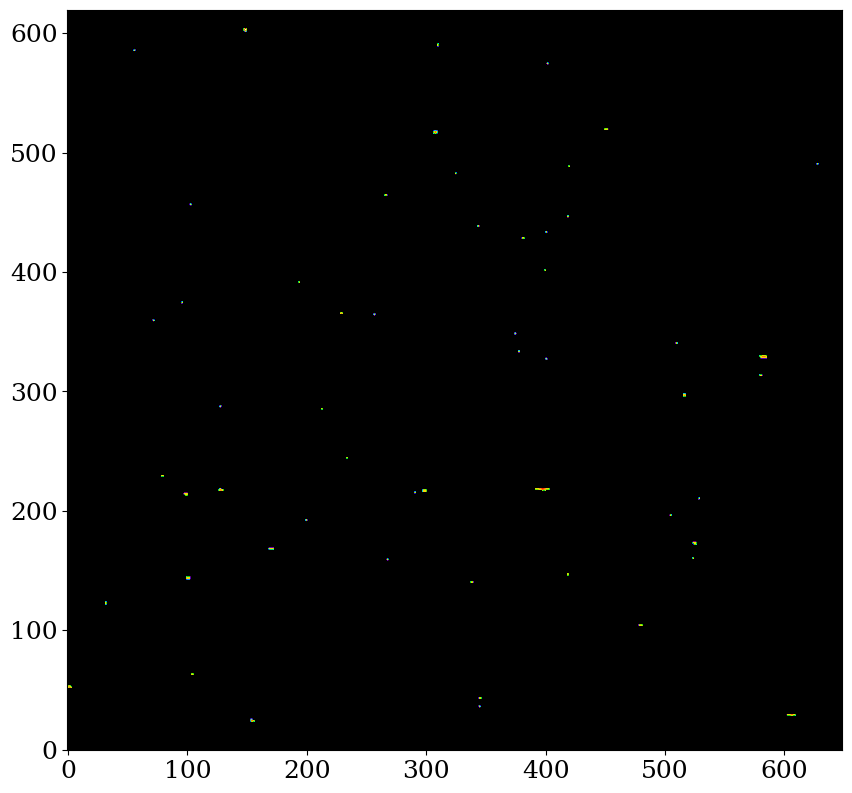

In [59]:
from astropy.visualization import simple_norm
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

norm1 = simple_norm(newa_arr, 'log', min_cut=1e-8, max_cut=10) 
ax.imshow(newa_arr,origin='lower', cmap=fo.custom_colormap(), norm=norm1)


In [63]:
hp_dir = '/data26s/mpecl/soumya_s/healpix_sky'
filename = f"{hp_dir}/healpix_erassc4_020_exp_1000_2300_nside13.fits"

In [70]:
test = fits.open(filename)[0].data
print(test)

None


In [71]:
import healpy as hp
NPIX = hp.nside2npix(NSIDE)

NameError: name 'NSIDE' is not defined